#1. Import Libraries

In [118]:
import sys
import subprocess
import warnings
warnings.filterwarnings("ignore")

try:
    import networkx
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "networkx"])

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

#2. Load Association Rules

In [ ]:
rules = pd.read_csv("../Data/Final_rules.csv")

rules.head()

,Unnamed: 0,antecedents,consequents,support,confidence,lift
0,353,Mouse Chartreuse 292,Monitor DarkKhaki 939,0.000121,0.045455,188.443182
1,352,Monitor DarkKhaki 939,Mouse Chartreuse 292,0.000121,0.500000,188.443182
2,4160,SSD Lime 581,Mouse MediumSpringGreen 253,0.000121,0.043478,144.200000
3,4161,Mouse MediumSpringGreen 253,SSD Lime 581,0.000121,0.400000,144.200000
4,4138,Speaker DarkRed 848,Mouse FireBrick 843,0.000121,0.400000,144.200000


#3. Filter Strong Rules

In [120]:
strong_rules = rules[
    (rules["confidence"] >= 0.1) &
    (rules["lift"] >= 2)
]

print("Strong rules shape:", strong_rules.shape)
strong_rules.head()

Strong rules shape: (68, 6)


,Unnamed: 0,antecedents,consequents,support,confidence,lift
1,352,Monitor DarkKhaki 939,Mouse Chartreuse 292,0.000121,0.500000,188.443182
3,4161,Mouse MediumSpringGreen 253,SSD Lime 581,0.000121,0.400000,144.200000
4,4138,Speaker DarkRed 848,Mouse FireBrick 843,0.000121,0.400000,144.200000
6,3627,Water Bottle DarkSlateBlue 296,Dumbbell DarkTurquoise 262,0.000121,0.181818,77.310023
9,417,Jeans AliceBlue 734,Jacket SlateBlue 368,0.000121,0.200000,73.702222


#4. Build Graph

In [121]:
G = nx.DiGraph()

for _, row in strong_rules.iterrows():
    G.add_edge(
        row["antecedents"],
        row["consequents"],
        weight=row["lift"]
    )

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 124
Number of edges: 68


#5. Apply PageRank

In [122]:
pagerank_scores = nx.pagerank(G, weight="weight")

pagerank_df = pd.DataFrame(
    pagerank_scores.items(),
    columns=["product", "score"]
)

pagerank_df = pagerank_df.sort_values(by="score", ascending=False)

pagerank_df.head(10)

,product,score
58,Lamp Chocolate 506,0.015429
100,Jeans LawnGreen 779,0.015429
94,Water Bottle PaleVioletRed 274,0.015429
3,SSD Lime 581,0.012601
21,Puzzle Orange 783,0.010572
17,Vacuum DodgerBlue 485,0.010572
27,Tennis Racket Tan 512,0.010572
25,Air Fryer MediumTurquoise 637,0.010572
15,Moisturizer Tomato 428,0.010572
13,Yoga Mat MistyRose 478,0.010572


#6. Top Important Products

In [123]:
top_products = pagerank_df.head(10)

print("Top 10 Products by PageRank:")
top_products

Top 10 Products by PageRank:


,product,score
58,Lamp Chocolate 506,0.015429
100,Jeans LawnGreen 779,0.015429
94,Water Bottle PaleVioletRed 274,0.015429
3,SSD Lime 581,0.012601
21,Puzzle Orange 783,0.010572
17,Vacuum DodgerBlue 485,0.010572
27,Tennis Racket Tan 512,0.010572
25,Air Fryer MediumTurquoise 637,0.010572
15,Moisturizer Tomato 428,0.010572
13,Yoga Mat MistyRose 478,0.010572


#7. Visualization

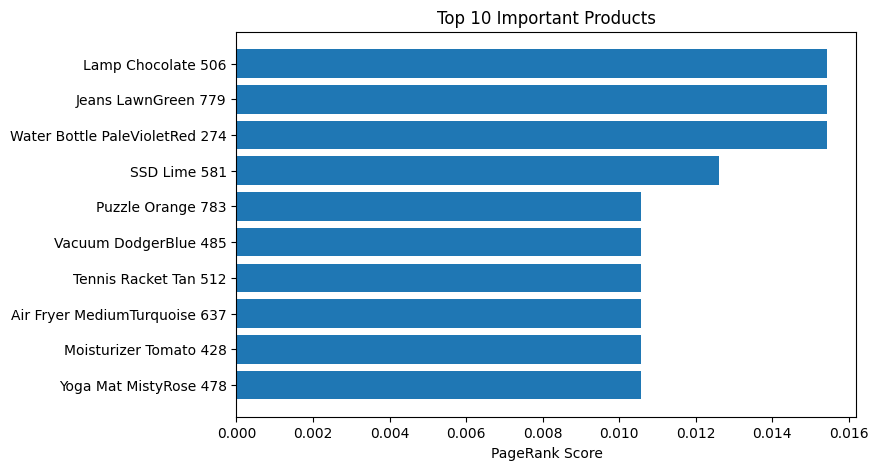

In [124]:
plt.figure(figsize=(8,5))

plt.barh(top_products["product"], top_products["score"])
plt.xlabel("PageRank Score")
plt.title("Top 10 Important Products")

plt.gca().invert_yaxis()
plt.show()

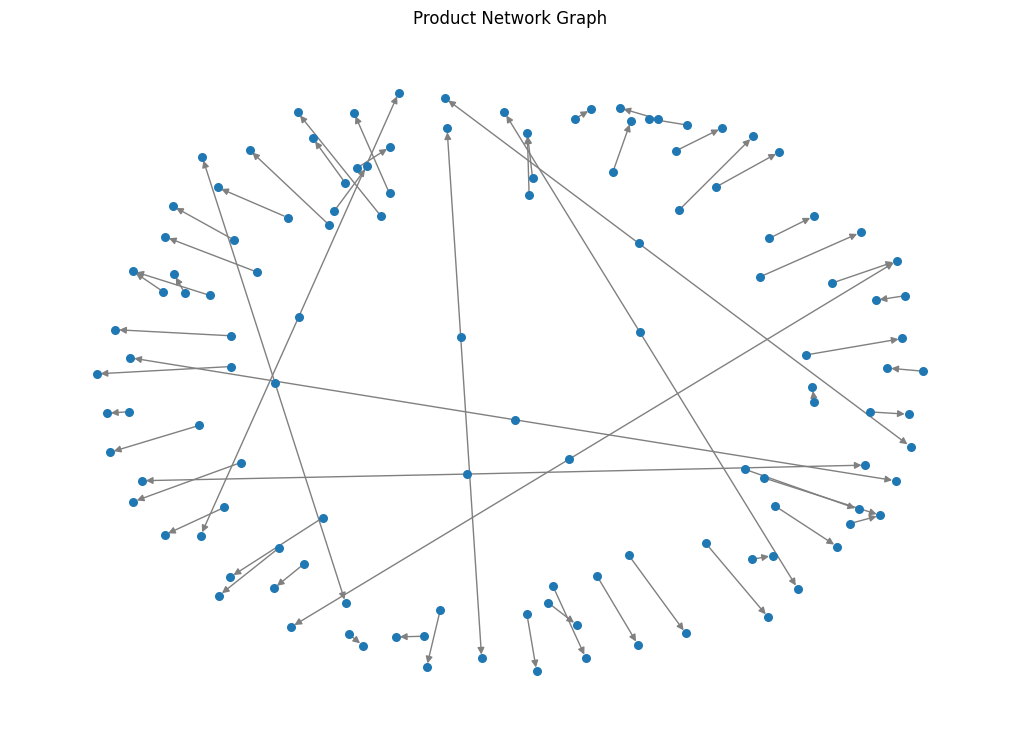

In [125]:
plt.figure(figsize=(10,7))

pos = nx.spring_layout(G, k=0.5)

nx.draw(
    G,
    pos,
    node_size=30,
    with_labels=False,
    edge_color="gray"
)

plt.title("Product Network Graph")
plt.show()

In [126]:
def recommend_with_pagerank(product_name, rules, pagerank_df, top_n=5):
    recs = rules[rules["antecedents"] == product_name]

    recs = recs.merge(
        pagerank_df,
        left_on="consequents",
        right_on="product",
        how="left"
    )

    recs = recs.sort_values(by=["lift", "score"], ascending=False)

    return recs[["consequents", "confidence", "lift", "score"]].head(top_n)